# Validating against the parent SWAN model — Abrolhos, Western Australia

A harder coast than the Dutch shoreface: **reef-fronted, complex bathymetry**, resolved by
Oceanum's Abrolhos 500 m SWAN nowcast.

The test is strict. The westernmost SWAN spectra sites become the boundary condition; interior
SWAN sites are held out as truth. The ray-traced operator transforms the boundary spectra to
each truth site and is scored against SWAN's own spectra there — measuring exactly what the
operator is meant to do: reproduce the parent model's last-stage transformation at a fraction
of its cost.

It also isolates **bottom friction**, which turns out to be the leading error term here.

Requirements: `uv sync --extra datamesh --extra notebooks` and `DATAMESH_TOKEN`.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Validated palette (dataviz reference instance, light mode)
SURFACE = "#fcfcfb"
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
BLUE, AQUA, YELLOW, ORANGE = "#2a78d6", "#1baf7a", "#eda100", "#eb6834"
LAND = "#e4e3dd"

# Sequential blue ramp, steps 100 -> 700 (one hue, light -> dark)
BLUE_STEPS = [
    "#cde2fb",
    "#b7d3f6",
    "#9ec5f4",
    "#86b6ef",
    "#6da7ec",
    "#5598e7",
    "#3987e5",
    "#2a78d6",
    "#256abf",
    "#1c5cab",
    "#184f95",
    "#104281",
    "#0d366b",
]
BLUES = LinearSegmentedColormap.from_list("blues", BLUE_STEPS)  # depth: shallow light -> deep dark
ENERGY = LinearSegmentedColormap.from_list("energy", ["#fcfcfb"] + BLUE_STEPS)

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.size": 10,
        "axes.edgecolor": "#d5d4cf",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "600",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "grid.color": "#ecebe6",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
    }
)


def label_end(ax, x, y, text, color, dx=6, dy=0):
    """Direct label at a series' right end (relief rule for low-contrast hues).

    Pass dy (points) to separate labels where two series converge.
    """
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        color=color,
        fontsize=9,
        fontweight="600",
        va="center",
        clip_on=False,
    )


def hs_of(efth, freqs, dirs):
    """Hm0 from a directional spectrum array (..., nf, ndir)."""
    from waveray.breaking import hm0

    return hm0(efth, freqs, dirs)


def metrics(pred, obs):
    import numpy as np

    ok = np.isfinite(pred) & np.isfinite(obs)
    p, o = pred[ok], obs[ok]
    return {
        "n": int(ok.sum()),
        "r": float(np.corrcoef(p, o)[0, 1]),
        "bias": float(np.mean(p - o)),
        "rmse": float(np.sqrt(np.mean((p - o) ** 2))),
        "si": float(np.sqrt(np.mean((p - o) ** 2)) / np.mean(o)),
    }

In [2]:
import os

import numpy as np
from oceanum.datamesh import Connector

from waveray import SiteModel, fetch_datamesh_bathymetry

assert os.environ.get("DATAMESH_TOKEN"), "DATAMESH_TOKEN is not set"

BBOX = (114.30, -28.95, 114.65, -28.60)
BATHY = "gebco_2025"
SPEC = "oceanum_wave_ec_abrol500m_spec_nowcast"
TIMES = ["2026-06-20T00:00:00Z", "2026-07-06T00:00:00Z"]
N_BOUNDARY = 5

conn = Connector()
grid = fetch_datamesh_bathymetry(BATHY, bbox=BBOX, positive="up")
ds = conn.query(
    {
        "datasource": SPEC,
        "geofilter": {"type": "bbox", "geom": list(BBOX)},
        "timefilter": {"times": TIMES},
    }
)
site_dim = next(d for d in ds["efth"].dims if d not in ("time", "freq", "dir"))
lons = np.atleast_1d(ds["lon"].values)
lats = np.atleast_1d(ds["lat"].values)
freqs, dirs = ds["freq"].values, ds["dir"].values
print(
    f"grid {grid.x.size} x {grid.y.size} @ ~{grid.spacing[0]:.0f} m; "
    f"{lons.size} SWAN sites; {ds.sizes['time']} timesteps"
)

grid 84 x 84 @ ~407 m; 56 SWAN sites; 385 timesteps


## Boundary and truth sites

Boundary = the five westernmost (most offshore) sites. Truth = the three shallowest interior
sites at least 3 km inside the boundary line.

In [3]:
order = np.argsort(lons)
b_idx = order[:N_BOUNDARY]
bpts = [(float(lons[i]), float(lats[i])) for i in b_idx]
efth_b = (
    ds["efth"]
    .isel({site_dim: b_idx})
    .rename({site_dim: "site"})
    .transpose("time", "site", "freq", "dir")
)

x_all, y_all = grid.to_local(lons, lats)
depth_all = grid.sample_depth(x_all, y_all)
x_bnd = x_all[b_idx].max()
cands = [
    i for i in order if i not in set(b_idx) and depth_all[i] > 3.0 and x_all[i] > x_bnd + 3000.0
]
truths = sorted(cands, key=lambda i: depth_all[i])[:3]
for i in truths:
    print(f"truth site ({lons[i]:.3f}, {lats[i]:.3f})  depth {depth_all[i]:.1f} m")

truth site (114.600, -28.650)  depth 4.3 m
truth site (114.600, -28.800)  depth 8.5 m
truth site (114.600, -28.850)  depth 10.5 m


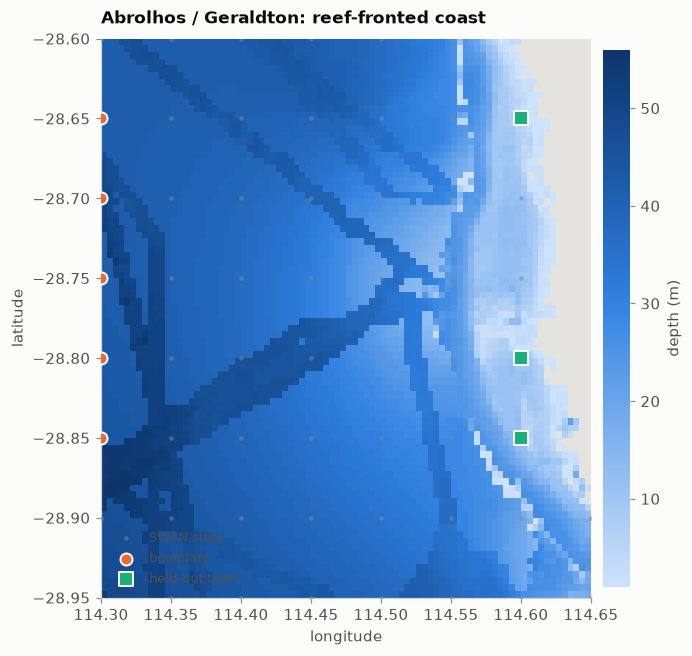

In [4]:
glon, glat = grid.to_lonlat(grid.x, grid.y)
depth_masked = np.where(grid.land, np.nan, grid.depth)

fig, ax = plt.subplots(figsize=(7.0, 6.6))
ax.set_facecolor(LAND)
pc = ax.pcolormesh(glon, glat, depth_masked, cmap=BLUES, shading="auto", rasterized=True)
cb = fig.colorbar(pc, ax=ax, pad=0.02, fraction=0.045)
cb.set_label("depth (m)", color=INK_2)
cb.outline.set_visible(False)
ax.scatter(lons, lats, s=9, c=INK_MUTED, alpha=0.5, linewidths=0, label="SWAN sites", zorder=3)
blon, blat = [p[0] for p in bpts], [p[1] for p in bpts]
ax.scatter(
    blon, blat, s=62, facecolor=ORANGE, edgecolor=SURFACE, linewidth=1.3, label="boundary", zorder=5
)
ax.scatter(
    lons[truths],
    lats[truths],
    s=74,
    marker="s",
    facecolor=AQUA,
    edgecolor=SURFACE,
    linewidth=1.3,
    label="held-out truth",
    zorder=5,
)
ax.set(xlabel="longitude", ylabel="latitude", title="Abrolhos / Geraldton: reef-fronted coast")
ax.set_aspect(1 / np.cos(np.deg2rad(28.8)))
ax.legend(loc="lower left", fontsize=8.5, labelcolor=INK_2)
plt.show()

## Scoring each truth site

In [5]:
results = {}
for i in truths:
    model = SiteModel.build(
        bathy=grid,
        target=(float(lons[i]), float(lats[i])),
        boundary_points=bpts,
        freqs=freqs,
        dirs=dirs,
    )
    hs_ray = hs_of(model.transform(efth_b).values, freqs, dirs)
    hs_swan = hs_of(
        ds["efth"].isel({site_dim: i}).transpose("time", "freq", "dir").values, freqs, dirs
    )
    results[i] = {
        "hs_ray": hs_ray,
        "hs_swan": hs_swan,
        "depth": depth_all[i],
        **metrics(hs_ray, hs_swan),
    }

print(f"{'site':>22} {'depth':>7} {'r':>7} {'bias':>8} {'rmse':>7} {'SI':>6}")
for i, r in results.items():
    print(
        f"({lons[i]:.3f}, {lats[i]:.3f}) {r['depth']:6.1f}m {r['r']:7.3f} "
        f"{r['bias']:+7.2f}m {r['rmse']:6.2f}m {r['si']:6.2f}"
    )

                  site   depth       r     bias    rmse     SI
(114.600, -28.650)    4.3m   0.944   +0.36m   0.60m   0.35
(114.600, -28.800)    8.5m   0.925   +0.18m   0.48m   0.22
(114.600, -28.850)   10.5m   0.980   -0.98m   1.05m   0.41


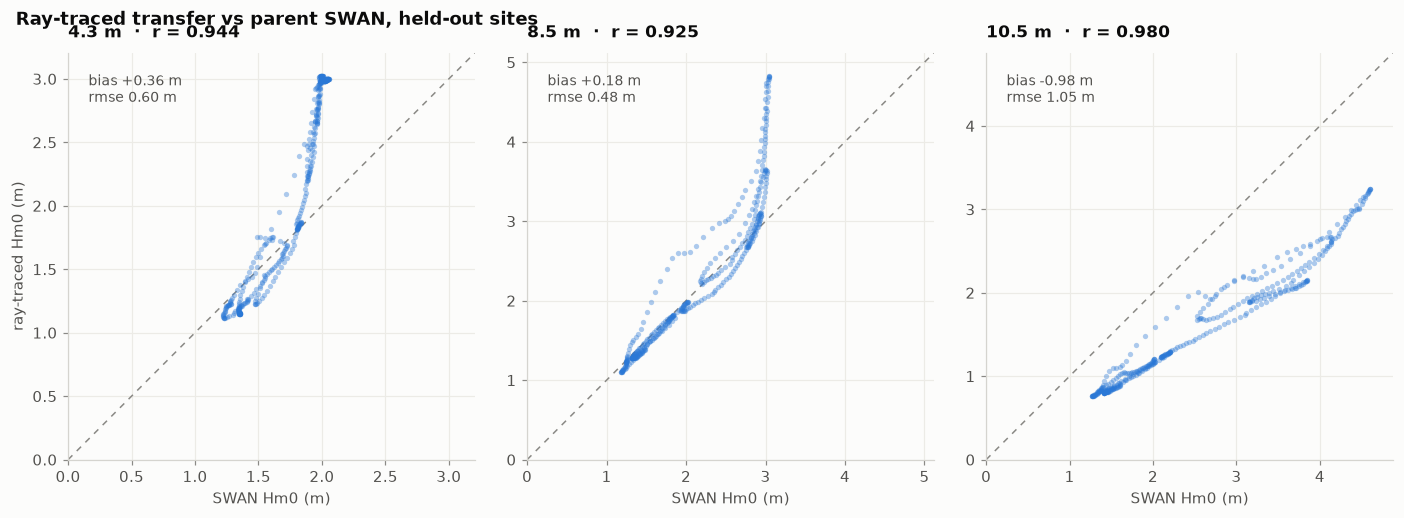

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.5))
for ax, (_i, r) in zip(axes, results.items(), strict=True):
    lim = float(max(r["hs_swan"].max(), r["hs_ray"].max())) * 1.06
    ax.grid(zorder=0)
    ax.plot([0, lim], [0, lim], color=INK_MUTED, lw=1, ls=(0, (4, 4)), zorder=2)
    ax.scatter(r["hs_swan"], r["hs_ray"], s=12, facecolor=BLUE, alpha=0.38, linewidths=0, zorder=3)
    ax.set(
        xlim=(0, lim),
        ylim=(0, lim),
        xlabel="SWAN Hm0 (m)",
        title=f"{r['depth']:.1f} m  ·  r = {r['r']:.3f}",
    )
    ax.set_aspect("equal")
    ax.annotate(
        f"bias {r['bias']:+.2f} m\nrmse {r['rmse']:.2f} m",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        va="top",
        fontsize=9,
        color=INK_2,
    )
axes[0].set_ylabel("ray-traced Hm0 (m)")
fig.suptitle(
    "Ray-traced transfer vs parent SWAN, held-out sites",
    x=0.02,
    ha="left",
    fontsize=11.5,
    fontweight="600",
    color=INK,
)
plt.tight_layout()
plt.show()

## Bottom friction is the leading error term here

The transfer coefficient carries a JONSWAP bottom-friction factor integrated along each ray
path. It is linear in energy, so it folds into the operator without breaking linearity.

Turning it off inflates the shallow-site wave heights substantially — over long shallow
approaches across the Abrolhos shelf, friction removes real energy. This is why
`cf_jonswap = 0.038` (the SWAN swell default) is **on by default**.

In [7]:
# Same site, same breaking, only the friction coefficient differs -- so the
# comparison isolates friction rather than confounding it with the breaking cap.
i = truths[1]
model_nofric = SiteModel.build(
    bathy=grid,
    target=(float(lons[i]), float(lats[i])),
    boundary_points=bpts,
    freqs=freqs,
    dirs=dirs,
    cf_jonswap=None,
)
hs_nofric = hs_of(model_nofric.transform(efth_b).values, freqs, dirs)
r = results[i]
m_nofric = metrics(hs_nofric, r["hs_swan"])

print(f"friction ON : r={r['r']:.3f}  bias={r['bias']:+.2f} m  rmse={r['rmse']:.2f} m")
print(
    f"friction OFF: r={m_nofric['r']:.3f}  bias={m_nofric['bias']:+.2f} m  "
    f"rmse={m_nofric['rmse']:.2f} m"
)

friction ON : r=0.925  bias=+0.18 m  rmse=0.48 m
friction OFF: r=0.940  bias=+1.11 m  rmse=1.32 m


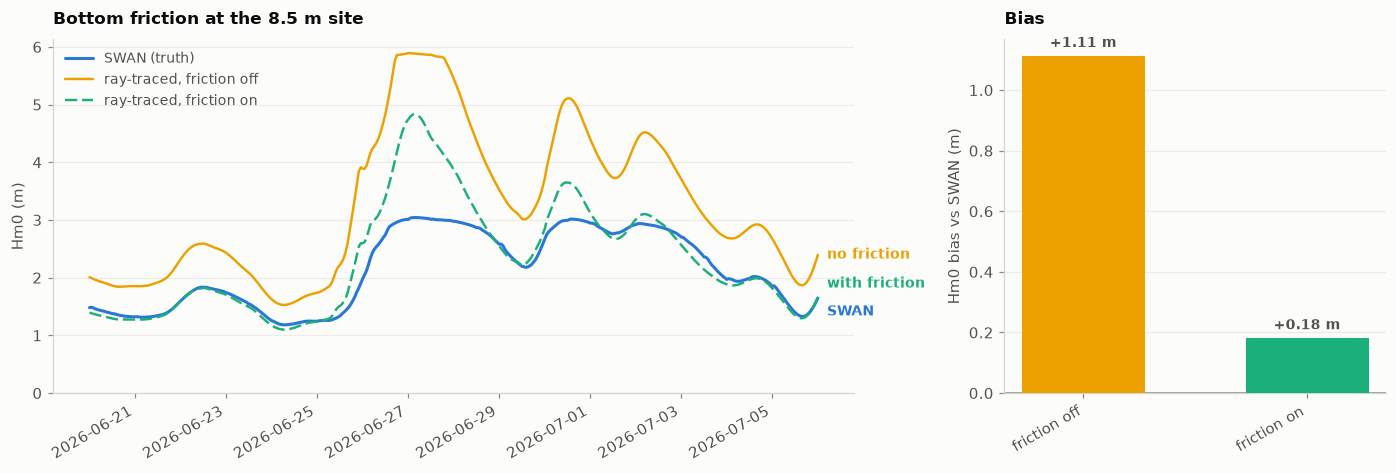

In [8]:
times = ds["time"].values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.4), gridspec_kw={"width_ratios": [2.1, 1]})
ax1.grid(axis="y", zorder=0)
ax1.plot(times, r["hs_swan"], color=BLUE, zorder=4)
ax1.plot(times, hs_nofric, color=YELLOW, lw=1.6, zorder=3)
ax1.plot(times, r["hs_ray"], color=AQUA, lw=1.6, ls=(0, (5, 2)), zorder=5)
label_end(ax1, times[-1], r["hs_swan"][-1], "SWAN", BLUE, dy=-9)
label_end(ax1, times[-1], hs_nofric[-1], "no friction", YELLOW)
label_end(ax1, times[-1], r["hs_ray"][-1], "with friction", AQUA, dy=9)
ax1.plot([], [], color=BLUE, label="SWAN (truth)")
ax1.plot([], [], color=YELLOW, lw=1.6, label="ray-traced, friction off")
ax1.plot([], [], color=AQUA, lw=1.6, ls=(0, (5, 2)), label="ray-traced, friction on")
ax1.legend(loc="upper left", fontsize=9, labelcolor=INK_2)
ax1.set(ylabel="Hm0 (m)", ylim=(0, None), title=f"Bottom friction at the {r['depth']:.1f} m site")
fig.autofmt_xdate()

bars = ["friction off", "friction on"]
vals = [m_nofric["bias"], r["bias"]]
ax2.grid(axis="y", zorder=0)
ax2.axhline(0, color=INK_MUTED, lw=1, zorder=2)
ax2.bar(bars, vals, color=[YELLOW, AQUA], width=0.55, zorder=3)
for b, v in zip(bars, vals, strict=True):
    ax2.annotate(
        f"{v:+.2f} m",
        xy=(b, v),
        xytext=(0, 6 if v > 0 else -14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="600",
        color=INK_2,
    )
ax2.set(ylabel="Hm0 bias vs SWAN (m)", title="Bias")
plt.tight_layout()
plt.show()

## Takeaway

On a reef-fronted coast the ray method still tracks the parent SWAN model closely in
correlation, with friction removing most of the shallow-water positive bias. The residual
bias at the most sheltered site is dominated by **bathymetry mismatch** — this notebook feeds
the operator GEBCO, while the parent SWAN model was built on the 250 m Australian Bathymetry
and Topography grid, which resolves reef structure GEBCO smooths away.

Two structural limits remain, and both are honest: rays block **binary** at reefs where SWAN
partially transmits energy, and there is no diffraction. Compare with the Dutch coast
notebook, where a smooth sandy shoreface gives r ≈ 0.99.